# MakeMore — Part 4: Becoming a Backprop Ninja

**Based on:** Andrej Karpathy's "Building makeMore Part 4: Becoming a Backprop Ninja"

## Overview

This notebook is about **deeply understanding backpropagation** by manually deriving and implementing every gradient — without calling `loss.backward()`. We work with a single-hidden-layer MLP with BatchNorm and decompose the forward pass into small atomic steps, then derive each gradient by hand.

The four progressive exercises:

| Exercise | Topic | Difficulty |
|---|---|---|
| **1** | Manual backprop through every intermediate variable | Tedious but mechanical |
| **2** | Fused gradient of the cross-entropy loss | One elegant expression |
| **3** | Fused gradient of the batch normalization layer | Requires chain rule & algebra |
| **4** | Full training loop with the manual backward pass | Putting it all together |

**Key insight:** once you can derive the gradient of BatchNorm and cross-entropy analytically, you can replace many lines of backprop with a single compact expression — exactly what PyTorch does internally.

**MLflow** tracks the final training run (Exercise 4).

---

## 1. Setup

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
import mlflow

%matplotlib inline

SEED = 2147483647

print(f"PyTorch version : {torch.__version__}")
print(f"MLflow  version : {mlflow.__version__}")

PyTorch version : 2.11.0+cu128
MLflow  version : 3.11.1


In [2]:
# ── Device Setup ──────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"  GPU : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
  GPU : NVIDIA GeForce RTX 5080 Laptop GPU
  VRAM: 16.6 GB


In [3]:
EXPERIMENT_NAME = "makemore-part4-backprop"
mlflow.set_experiment(EXPERIMENT_NAME)
print(f"MLflow experiment: '{EXPERIMENT_NAME}'")

2026/04/24 13:54:40 INFO mlflow.tracking.fluent: Experiment with name 'makemore-part4-backprop' does not exist. Creating a new experiment.


MLflow experiment: 'makemore-part4-backprop'


## 2. Data Loading & Dataset Construction

In [4]:
with open('data/names.txt', 'r') as f:
    words = f.read().splitlines()

chars = sorted(set(''.join(words)))
stoi  = {s: i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos  = {i: s for s, i in stoi.items()}
VOCAB_SIZE = len(itos)   # 27

print(f"Words: {len(words):,}  |  Vocab size: {VOCAB_SIZE}")

Words: 32,033  |  Vocab size: 27


In [5]:
BLOCK_SIZE = 3

def build_dataset(words: list[str]) -> tuple[torch.Tensor, torch.Tensor]:
    X, Y = [], []
    for w in words:
        context = [0] * BLOCK_SIZE
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    return torch.tensor(X).to(device), torch.tensor(Y).to(device)


random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr,  Ytr  = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte,  Yte  = build_dataset(words[n2:])

print(f"Train : {Xtr.shape}  |  Dev : {Xdev.shape}  |  Test : {Xte.shape}")
print(f"Device: {Xtr.device}")

Train : torch.Size([182625, 3])  |  Dev : torch.Size([22655, 3])  |  Test : torch.Size([22866, 3])
Device: cuda:0


---
## 3. Model Initialization

For this notebook we use a **flat (non-modular) parameter style** — individual tensors rather than layer classes.  
This makes the manual backprop easier to follow step by step.

Architecture: `Embedding → Linear(BN) → Tanh → Linear → cross_entropy`

In [6]:
N_EMBD   = 10
N_HIDDEN = 64

def init_params(
    vocab_size: int,
    block_size: int,
    n_embd: int,
    n_hidden: int,
    seed: int = SEED,
    device: torch.device = torch.device("cpu"),
) -> list[torch.Tensor]:
    """Initialize all model parameters.

    Uses non-standard initializations deliberately so a wrong backward
    pass will show up clearly when compared to PyTorch's autograd.
    Returns [C, W1, b1, W2, b2, bngain, bnbias].
    """
    g  = torch.Generator().manual_seed(seed)
    # Embedding table
    C      = torch.randn((vocab_size, n_embd),            generator=g).to(device)
    # Layer 1 — Kaiming-scaled weight, small random bias
    W1     = (torch.randn((n_embd * block_size, n_hidden), generator=g)
              * (5 / 3) / ((n_embd * block_size) ** 0.5)).to(device)
    b1     = (torch.randn(n_hidden, generator=g) * 0.1).to(device)
    # Layer 2
    W2     = (torch.randn((n_hidden, vocab_size), generator=g) * 0.1).to(device)
    b2     = (torch.randn(vocab_size,             generator=g) * 0.1).to(device)
    # BatchNorm learnable params (init near identity but not exactly)
    bngain = (torch.randn((1, n_hidden), generator=g) * 0.1 + 1.0).to(device)
    bnbias = (torch.randn((1, n_hidden), generator=g) * 0.1      ).to(device)

    params = [C, W1, b1, W2, b2, bngain, bnbias]
    for p in params:
        p.requires_grad = True

    total = sum(p.nelement() for p in params)
    print(f"Parameters: {total:,}  (device: {device})")
    return params


C, W1, b1, W2, b2, bngain, bnbias = init_params(
    VOCAB_SIZE, BLOCK_SIZE, N_EMBD, N_HIDDEN, device=device
)

Parameters: 4,137  (device: cuda)


---
## 4. The "Chunkated" Forward Pass

We break the forward pass into many **small atomic steps**, each stored in a separate variable.  
Calling `.retain_grad()` on each intermediate tensor lets PyTorch store its gradient,  
so we can compare our hand-derived gradients against the ground truth.

The full computation graph:
```
C, Xb → emb → embcat → hprebn → (BatchNorm) → hpreact → h → logits
                                                              ↓
                                              logit_maxes → norm_logits → counts
                                                            → counts_sum → counts_sum_inv
                                                            → probs → logprobs → loss
```

In [7]:
BATCH_SIZE = 32
n          = BATCH_SIZE   # short alias used in grad formulas

g_batch = torch.Generator().manual_seed(SEED)
ix      = torch.randint(0, Xtr.shape[0], (BATCH_SIZE,), generator=g_batch)
Xb, Yb  = Xtr[ix], Ytr[ix]

# ── Forward pass ──────────────────────────────────────────────────────────────
emb     = C[Xb]                                        # (B, block_size, n_embd)
embcat  = emb.view(emb.shape[0], -1)                   # (B, block_size*n_embd)

# Layer 1 pre-activation
hprebn  = embcat @ W1 + b1                             # (B, n_hidden)

# BatchNorm — decomposed step by step
bnmeani     = 1/n * hprebn.sum(0, keepdim=True)            # batch mean
bndiff      = hprebn - bnmeani                             # centered
bndiff2     = bndiff**2                                    # squared diff
bnvar       = 1/(n-1) * bndiff2.sum(0, keepdim=True)       # variance (Bessel's correction)
bnvar_inv   = (bnvar + 1e-5)**-0.5                         # inverse std
bnraw       = bndiff * bnvar_inv                           # normalized
hpreact     = bngain * bnraw + bnbias                      # scaled + shifted

# Non-linearity
h       = torch.tanh(hpreact)                          # (B, n_hidden)

# Layer 2
logits  = h @ W2 + b2                                  # (B, vocab_size)

# Manual cross-entropy (decomposed for backprop practice)
logit_maxes  = logits.max(1, keepdim=True).values
norm_logits  = logits - logit_maxes              # numerical stability
counts       = norm_logits.exp()
counts_sum   = counts.sum(1, keepdim=True)
counts_sum_inv = counts_sum**-1
probs        = counts * counts_sum_inv
logprobs     = probs.log()
loss         = -logprobs[range(n), Yb].mean()

# ── Run PyTorch autograd (reference gradients) ────────────────────────────────
for p in [C, W1, b1, W2, b2, bngain, bnbias]:
    p.grad = None
for t in [logprobs, probs, counts, counts_sum, counts_sum_inv,
          norm_logits, logit_maxes, logits, h, hpreact, bnraw,
          bnvar_inv, bnvar, bndiff2, bndiff, hprebn, bnmeani, embcat, emb]:
    t.retain_grad()

loss.backward()
print(f"Forward pass complete.  loss = {loss.item():.4f}")

Forward pass complete.  loss = 3.4938


## 5. Gradient Comparison Utility

`cmp(name, d_manual, t)` checks our manual gradient `d_manual` against `t.grad` (PyTorch's autograd result).

- **exact** — every single element matches bit-for-bit
- **approximate** — all elements are within numerical tolerance (`torch.allclose`)
- **maxdiff** — the largest absolute difference (should be < 1e-7 for correctness)

In [8]:
def cmp(name: str, d_manual: torch.Tensor, t: torch.Tensor) -> None:
    """Compare manual gradient d_manual against t.grad from PyTorch autograd."""
    exact   = torch.all(d_manual == t.grad).item()
    approx  = torch.allclose(d_manual, t.grad)
    maxdiff = (d_manual - t.grad).abs().max().item()
    status  = "✓" if approx else "✗"
    print(f"{status} {name:18s} | exact: {str(exact):<5} | approx: {str(approx):<5} | maxdiff: {maxdiff:.2e}")

---
## 6. Exercise 1 — Manual Backprop Through Every Variable

We derive `d<var>` for **every** intermediate tensor in the forward pass, working backward from `loss` to `C`.  
The chain rule connects each step: if `y = f(x)`, then `dx = dy * f'(x)`.

### Key derivative facts used:
| Operation | Forward | Backward |
|---|---|---|
| `z = -mean(logprobs[range(n), Yb])` | scalar | `dlogprobs[i,j] = -1/n if j==Yb[i]` |
| `logprobs = log(probs)` | elem-wise | `dprobs = dlogprobs / probs` |
| `probs = counts * counts_sum_inv` | broadcast | sum over broadcast axes |
| `counts_sum_inv = counts_sum^-1` | elem-wise | `-counts_sum^-2 * d_inv` |
| `counts = exp(norm_logits)` | elem-wise | `counts * dnorm_logits` |
| `norm_logits = logits - max` | subtract max | gradient flows to logits; max gets `-sum` |
| `h = tanh(hpreact)` | elem-wise | `(1 - h²) * dh` |
| `bnraw = bndiff * bnvar_inv` | broadcast | sum over broadcast axis |

In [9]:
# ── loss = -logprobs[range(n), Yb].mean() ───────────────────────────────────
# Only the selected positions contribute; gradient is -1/n
dlogprobs = torch.zeros_like(logprobs)
dlogprobs[range(n), Yb] = -1.0 / n

# ── logprobs = log(probs) ────────────────────────────────────────────────────
dprobs = (1.0 / probs) * dlogprobs

# ── probs = counts * counts_sum_inv  (broadcast: counts_sum_inv is (B,1)) ───
dcounts_sum_inv = (counts * dprobs).sum(1, keepdim=True)
dcounts         = counts_sum_inv * dprobs

# ── counts_sum_inv = counts_sum^-1 ───────────────────────────────────────────
dcounts_sum = (-counts_sum**-2) * dcounts_sum_inv

# ── counts_sum = counts.sum(1) — gradient fans out to every element ──────────
dcounts += torch.ones_like(counts) * dcounts_sum

# ── counts = exp(norm_logits) ────────────────────────────────────────────────
dnorm_logits = counts * dcounts

# ── norm_logits = logits - logit_maxes ───────────────────────────────────────
# Gradient flows straight through the subtraction to logits.
# logit_maxes is chosen by argmax (no gradient through argmax); its contribution
# is a column sum negated.
dlogits      = dnorm_logits.clone()
dlogit_maxes = (-dnorm_logits).sum(1, keepdim=True)

# ── logit_maxes = logits.max(1).values — one-hot selector ───────────────────
dlogits += F.one_hot(logits.max(1).indices, num_classes=logits.shape[1]) * dlogit_maxes

# ── logits = h @ W2 + b2 ─────────────────────────────────────────────────────
dh  = dlogits @ W2.T
dW2 = h.T @ dlogits
db2 = dlogits.sum(0)

# ── h = tanh(hpreact) ────────────────────────────────────────────────────────
dhpreact = (1.0 - h**2) * dh

# ── hpreact = bngain * bnraw + bnbias  (bngain/bnbias are (1, n_hidden)) ─────
dbngain  = (bnraw * dhpreact).sum(0, keepdim=True)
dbnbias  = dhpreact.sum(0, keepdim=True)
dbnraw   = bngain * dhpreact

# ── bnraw = bndiff * bnvar_inv  (bnvar_inv is (1, n_hidden)) ─────────────────
dbndiff    = bnvar_inv * dbnraw
dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)

# ── bnvar_inv = (bnvar + 1e-5)^-0.5 ─────────────────────────────────────────
dbnvar = (-0.5 * (bnvar + 1e-5)**-1.5) * dbnvar_inv

# ── bnvar = 1/(n-1) * bndiff2.sum(0) ────────────────────────────────────────
dbndiff2 = (1.0 / (n - 1)) * torch.ones_like(bndiff2) * dbnvar

# ── bndiff2 = bndiff^2 ───────────────────────────────────────────────────────
dbndiff += 2 * bndiff * dbndiff2

# ── bndiff = hprebn - bnmeani ────────────────────────────────────────────────
dhprebn  = dbndiff.clone()
dbnmeani = (-dbndiff).sum(0)

# ── bnmeani = (1/n) * hprebn.sum(0) ─────────────────────────────────────────
dhprebn += (1.0 / n) * torch.ones_like(hprebn) * dbnmeani

# ── hprebn = embcat @ W1 + b1 ────────────────────────────────────────────────
dembcat = dhprebn @ W1.T
dW1     = embcat.T @ dhprebn
db1     = dhprebn.sum(0)

# ── embcat = emb.view(B, -1) ──────────────────────────────────────────────────
demb = dembcat.view(emb.shape)

# ── emb = C[Xb] — scatter gradients back to each row of C ───────────────────
# Vectorized version: equivalent to the nested loop but GPU-friendly
dC = torch.zeros_like(C)
dC.index_add_(0, Xb.view(-1), demb.view(-1, N_EMBD))

print("Manual backprop computed. Comparing against PyTorch autograd:")
print()

Manual backprop computed. Comparing against PyTorch autograd:



In [10]:
# ── Verification ─────────────────────────────────────────────────────────────
cmp('logprobs',      dlogprobs,      logprobs)
cmp('probs',         dprobs,         probs)
cmp('counts_sum_inv',dcounts_sum_inv,counts_sum_inv)
cmp('counts_sum',    dcounts_sum,    counts_sum)
cmp('counts',        dcounts,        counts)
cmp('norm_logits',   dnorm_logits,   norm_logits)
cmp('logit_maxes',   dlogit_maxes,   logit_maxes)
cmp('logits',        dlogits,        logits)
cmp('h',             dh,             h)
cmp('W2',            dW2,            W2)
cmp('b2',            db2,            b2)
cmp('hpreact',       dhpreact,       hpreact)
cmp('bngain',        dbngain,        bngain)
cmp('bnbias',        dbnbias,        bnbias)
cmp('bnraw',         dbnraw,         bnraw)
cmp('bnvar_inv',     dbnvar_inv,     bnvar_inv)
cmp('bnvar',         dbnvar,         bnvar)
cmp('bndiff2',       dbndiff2,       bndiff2)
cmp('bndiff',        dbndiff,        bndiff)
cmp('bnmeani',       dbnmeani,       bnmeani)
cmp('hprebn',        dhprebn,        hprebn)
cmp('embcat',        dembcat,        embcat)
cmp('W1',            dW1,            W1)
cmp('b1',            db1,            b1)
cmp('emb',           demb,           emb)
cmp('C',             dC,             C)

✓ logprobs           | exact: True  | approx: True  | maxdiff: 0.00e+00
✓ probs              | exact: True  | approx: True  | maxdiff: 0.00e+00
✓ counts_sum_inv     | exact: True  | approx: True  | maxdiff: 0.00e+00
✓ counts_sum         | exact: True  | approx: True  | maxdiff: 0.00e+00
✓ counts             | exact: True  | approx: True  | maxdiff: 0.00e+00
✓ norm_logits        | exact: True  | approx: True  | maxdiff: 0.00e+00
✓ logit_maxes        | exact: True  | approx: True  | maxdiff: 0.00e+00
✓ logits             | exact: True  | approx: True  | maxdiff: 0.00e+00
✓ h                  | exact: True  | approx: True  | maxdiff: 0.00e+00
✓ W2                 | exact: True  | approx: True  | maxdiff: 0.00e+00
✓ b2                 | exact: True  | approx: True  | maxdiff: 0.00e+00
✓ hpreact            | exact: False | approx: True  | maxdiff: 4.66e-10
✓ bngain             | exact: False | approx: True  | maxdiff: 1.86e-09
✓ bnbias             | exact: False | approx: True  | maxdiff: 3

---
## 7. Exercise 2 — Fused Cross-Entropy Backward

The multi-step cross-entropy decomposition (logit_maxes → counts → probs → …) can be collapsed into a **single closed-form expression**.

**Derivation:**

$$\mathcal{L} = -\frac{1}{n}\sum_i \log\frac{e^{z_{i,y_i}}}{\sum_j e^{z_{i,j}}}$$

$$\frac{\partial \mathcal{L}}{\partial z_{i,j}} = \frac{1}{n}\left(\text{softmax}(z_i)_j - \mathbf{1}[j = y_i]\right)$$

In code this is just three lines:

In [11]:
# Forward: use F.cross_entropy (equivalent to our decomposed version)
loss_fast = F.cross_entropy(logits, Yb)
print(f"loss_fast={loss_fast.item():.6f}  diff={abs(loss_fast.item()-loss.item()):.2e}")

# Fused backward — one expression instead of ~10 lines
dlogits_fast = F.softmax(logits, dim=1)
dlogits_fast[range(n), Yb] -= 1
dlogits_fast /= n

print("\nFused cross-entropy gradient vs PyTorch autograd:")
cmp('logits (fused)', dlogits_fast, logits)

loss_fast=3.493773  diff=2.38e-07

Fused cross-entropy gradient vs PyTorch autograd:
✓ logits (fused)     | exact: False | approx: True  | maxdiff: 5.59e-09


---
## 8. Exercise 3 — Fused BatchNorm Backward

The BatchNorm backward (7 intermediate variables: `bndiff`, `bndiff2`, `bnvar`, …) can be collapsed into a **single expression**.

**Derivation** (given $\frac{\partial L}{\partial y} = $ `dhpreact`, and $\hat{x}$ = `bnraw`, $\sigma^{-1}$ = `bnvar_inv`):

$$\frac{\partial L}{\partial x_i} = \frac{\gamma \sigma^{-1}}{n}\left(n\,\frac{\partial L}{\partial y_i} - \sum_j\frac{\partial L}{\partial y_j} - \frac{n}{n-1}\hat{x}_i \sum_j \frac{\partial L}{\partial y_j}\hat{x}_j\right)$$

In [12]:
# Forward: verify the fused BN expression matches step-by-step version
hpreact_fast = (
    bngain
    * (hprebn - hprebn.mean(0, keepdim=True))
    / torch.sqrt(hprebn.var(0, keepdim=True, unbiased=True) + 1e-5)
    + bnbias
)
print(f"hpreact_fast max diff from step-by-step: {(hpreact_fast - hpreact).abs().max().item():.2e}")

# Fused backward — one expression instead of ~9 lines
dhprebn_fast = (
    bngain * bnvar_inv / n
    * (n * dhpreact - dhpreact.sum(0) - n / (n - 1) * bnraw * (dhpreact * bnraw).sum(0))
)

print("\nFused BatchNorm gradient vs PyTorch autograd:")
cmp('hprebn (fused)', dhprebn_fast, hprebn)

hpreact_fast max diff from step-by-step: 4.77e-07

Fused BatchNorm gradient vs PyTorch autograd:
✓ hprebn (fused)     | exact: False | approx: True  | maxdiff: 9.31e-10


---
## 9. Exercise 4 — Full Training with Manual Backward & MLflow

We now train the complete model using **only our hand-derived gradients** — no `loss.backward()`.  
The entire loop runs inside `torch.no_grad()` since we manage gradients manually.

We use the **two fused expressions** from Exercises 2 & 3 for efficiency.

In [13]:
N_EMBD_TRAIN   = 10
N_HIDDEN_TRAIN = 200
NUM_STEPS      = 200_000
BATCH_SIZE_TR  = 32
LR_HIGH        = 0.1
LR_LOW         = 0.01
LR_DECAY       = 100_000

# Fresh parameter initialization for the main training run
C2, W1_2, b1_2, W2_2, b2_2, bngain2, bnbias2 = init_params(
    VOCAB_SIZE, BLOCK_SIZE, N_EMBD_TRAIN, N_HIDDEN_TRAIN, device=device
)
params_train = [C2, W1_2, b1_2, W2_2, b2_2, bngain2, bnbias2]

Parameters: 12,297  (device: cuda)


In [14]:
def train_manual_backprop(
    params: list[torch.Tensor],
    Xtr: torch.Tensor,
    Ytr: torch.Tensor,
    block_size: int,
    n_embd: int,
    num_steps: int    = 200_000,
    batch_size: int   = 32,
    lr_high: float    = 0.1,
    lr_low: float     = 0.01,
    lr_decay: int     = 100_000,
    log_every: int    = 10_000,
    seed: int         = SEED,
) -> list[float]:
    """Train with a fully manual backward pass.

    Uses the fused cross-entropy and batchnorm gradients from Exercises 2 & 3.
    Runs entirely inside torch.no_grad() — PyTorch autograd is never invoked.
    Returns the per-step log10 loss list.
    """
    C, W1, b1, W2, b2, bngain, bnbias = params
    n = batch_size
    g = torch.Generator().manual_seed(seed)
    lossi = []

    with torch.no_grad():
        for step in range(num_steps):
            # ── Minibatch ─────────────────────────────────────────────────────
            ix     = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
            Xb, Yb = Xtr[ix], Ytr[ix]

            # ── Forward pass ──────────────────────────────────────────────────
            emb    = C[Xb]
            embcat = emb.view(emb.shape[0], -1)

            hprebn = embcat @ W1 + b1

            # BatchNorm (fused)
            bnmean  = hprebn.mean(0, keepdim=True)
            bnvar   = hprebn.var(0,  keepdim=True, unbiased=True)
            bnvar_inv = (bnvar + 1e-5)**-0.5
            bnraw   = (hprebn - bnmean) * bnvar_inv
            hpreact = bngain * bnraw + bnbias

            h      = torch.tanh(hpreact)
            logits = h @ W2 + b2
            loss   = F.cross_entropy(logits, Yb)

            # ── Manual backward pass ──────────────────────────────────────────
            # Exercise 2: fused cross-entropy gradient
            dlogits = F.softmax(logits, dim=1)
            dlogits[range(n), Yb] -= 1
            dlogits /= n

            # Layer 2
            dh  = dlogits @ W2.T
            dW2 = h.T @ dlogits
            db2 = dlogits.sum(0)

            # tanh
            dhpreact = (1.0 - h**2) * dh

            # BatchNorm params
            dbngain = (bnraw * dhpreact).sum(0, keepdim=True)
            dbnbias = dhpreact.sum(0, keepdim=True)

            # Exercise 3: fused batchnorm gradient
            dhprebn = (
                bngain * bnvar_inv / n
                * (n * dhpreact - dhpreact.sum(0)
                   - n / (n - 1) * bnraw * (dhpreact * bnraw).sum(0))
            )

            # Layer 1
            dembcat = dhprebn @ W1.T
            dW1     = embcat.T @ dhprebn
            db1     = dhprebn.sum(0)

            # Embedding scatter (vectorized, GPU-safe)
            demb = dembcat.view(emb.shape)
            dC   = torch.zeros_like(C)
            dC.index_add_(0, Xb.view(-1), demb.view(-1, n_embd))

            grads = [dC, dW1, db1, dW2, db2, dbngain, dbnbias]

            # ── Parameter update ──────────────────────────────────────────────
            lr = lr_high if step < lr_decay else lr_low
            for p, grad in zip(params, grads):
                p.data -= lr * grad

            # ── Logging ───────────────────────────────────────────────────────
            lossi.append(loss.log10().item())
            if step % log_every == 0 or step == num_steps - 1:
                print(f"  step {step+1:>7,}/{num_steps:,} | loss {loss.item():.4f}")

    return lossi

Training with manual backward pass...

  step       1/200,000 | loss 3.8206
  step  10,001/200,000 | loss 2.0300
  step  20,001/200,000 | loss 2.3739
  step  30,001/200,000 | loss 2.1639
  step  40,001/200,000 | loss 2.1016
  step  50,001/200,000 | loss 2.3246
  step  60,001/200,000 | loss 1.9397
  step  70,001/200,000 | loss 2.1363
  step  80,001/200,000 | loss 2.2931
  step  90,001/200,000 | loss 2.0948
  step 100,001/200,000 | loss 2.2668
  step 110,001/200,000 | loss 2.1224
  step 120,001/200,000 | loss 2.2913
  step 130,001/200,000 | loss 1.7604
  step 140,001/200,000 | loss 2.1262
  step 150,001/200,000 | loss 2.4242
  step 160,001/200,000 | loss 2.0250
  step 170,001/200,000 | loss 1.7061
  step 180,001/200,000 | loss 2.6121
  step 190,001/200,000 | loss 2.2716
  step 200,000/200,000 | loss 2.2019


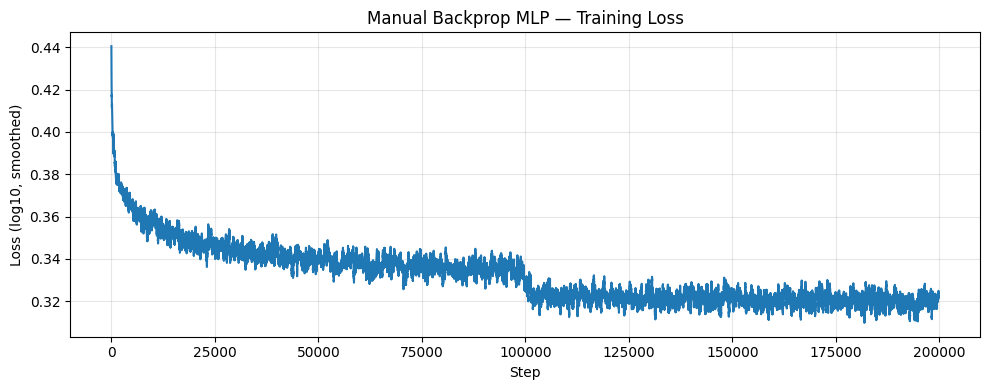


Training complete.


In [15]:
mlflow.end_run()  # close any stale run

with mlflow.start_run(run_name="manual-backprop"):

    mlflow.log_params({
        "model"          : "manual-backprop-mlp",
        "block_size"     : BLOCK_SIZE,
        "n_embd"         : N_EMBD_TRAIN,
        "n_hidden"       : N_HIDDEN_TRAIN,
        "num_steps"      : NUM_STEPS,
        "batch_size"     : BATCH_SIZE_TR,
        "lr_high"        : LR_HIGH,
        "lr_low"         : LR_LOW,
        "lr_decay"       : LR_DECAY,
        "device"         : str(device),
        "total_params"   : sum(p.nelement() for p in params_train),
        "backprop_mode"  : "manual",
    })

    print("Training with manual backward pass...\n")
    lossi = train_manual_backprop(
        params_train, Xtr, Ytr,
        block_size=BLOCK_SIZE,
        n_embd=N_EMBD_TRAIN,
        num_steps=NUM_STEPS,
        batch_size=BATCH_SIZE_TR,
        lr_high=LR_HIGH,
        lr_low=LR_LOW,
        lr_decay=LR_DECAY,
    )

    # Log smoothed loss to MLflow
    for step in range(0, len(lossi), 1000):
        avg = sum(lossi[step:step+1000]) / min(1000, len(lossi) - step)
        mlflow.log_metric("train_loss_log10", avg, step=step)

    # Loss curve
    smooth_k = 200
    smoothed  = [sum(lossi[i:i+smooth_k])/smooth_k for i in range(len(lossi) - smooth_k)]
    fig, ax   = plt.subplots(figsize=(10, 4))
    ax.plot(smoothed)
    ax.set_xlabel("Step")
    ax.set_ylabel("Loss (log10, smoothed)")
    ax.set_title("Manual Backprop MLP — Training Loss")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("p4_loss_curve.png", dpi=100)
    mlflow.log_artifact("p4_loss_curve.png")
    plt.show()

print("\nTraining complete.")

---
## 10. Batch Norm Calibration & Evaluation

During training, BatchNorm uses **batch statistics** (mean/std of the current mini-batch).  
For inference we need **stable statistics** from the full training set.  
We do a single forward pass over all of `Xtr` to compute frozen `bnmean_cal` and `bnvar_cal`.

In [16]:
C2, W1_2, b1_2, W2_2, b2_2, bngain2, bnbias2 = params_train

@torch.no_grad()
def calibrate_bn() -> tuple[torch.Tensor, torch.Tensor]:
    """Compute BatchNorm statistics over the full training set."""
    emb     = C2[Xtr]
    embcat  = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1_2 + b1_2
    bnmean  = hpreact.mean(0, keepdim=True)
    bnvar   = hpreact.var(0,  keepdim=True, unbiased=True)
    return bnmean, bnvar


bnmean_cal, bnvar_cal = calibrate_bn()
print(f"BN calibrated:  mean shape={tuple(bnmean_cal.shape)}  var range=[{bnvar_cal.min():.4f}, {bnvar_cal.max():.4f}]")

BN calibrated:  mean shape=(1, 200)  var range=[1.2667, 9.7187]


In [17]:
@torch.no_grad()
def evaluate_split(split: str) -> float:
    """Cross-entropy loss on a data split using calibrated BN statistics."""
    X, Y = {"train": (Xtr, Ytr), "val": (Xdev, Ydev), "test": (Xte, Yte)}[split]
    emb     = C2[X]
    embcat  = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1_2 + b1_2
    hpreact = bngain2 * (hpreact - bnmean_cal) * (bnvar_cal + 1e-5)**-0.5 + bnbias2
    h       = torch.tanh(hpreact)
    logits  = h @ W2_2 + b2_2
    return F.cross_entropy(logits, Y).item()


train_loss = evaluate_split("train")
val_loss   = evaluate_split("val")
test_loss  = evaluate_split("test")

print(f"Train loss : {train_loss:.4f}")
print(f"Val   loss : {val_loss:.4f}")
print(f"Test  loss : {test_loss:.4f}")

mlflow.end_run()
with mlflow.start_run(run_name="manual-backprop-eval"):
    mlflow.log_metrics({
        "train_loss": train_loss,
        "val_loss"  : val_loss,
        "test_loss" : test_loss,
    })

Train loss : 2.0705
Val   loss : 2.1094
Test  loss : 2.1081


---
## 11. Sampling Generated Names

In [18]:
@torch.no_grad()
def sample_names(num_samples: int = 20, seed: int = SEED + 10) -> list[str]:
    """Autoregressively sample names using calibrated BN stats.
    Everything runs on CPU so seeded torch.multinomial is reproducible.
    """
    # Move weights to CPU for sampling
    C_s      = C2.cpu()
    W1_s     = W1_2.cpu()
    b1_s     = b1_2.cpu()
    W2_s     = W2_2.cpu()
    b2_s     = b2_2.cpu()
    bngain_s = bngain2.cpu()
    bnbias_s = bnbias2.cpu()
    bnmean_s = bnmean_cal.cpu()
    bnvar_s  = bnvar_cal.cpu()

    g       = torch.Generator().manual_seed(seed)
    samples = []

    for _ in range(num_samples):
        out     = []
        context = [0] * BLOCK_SIZE
        while True:
            emb     = C_s[torch.tensor([context])]           # (1, block_size, n_embd)
            embcat  = emb.view(1, -1)
            hpreact = embcat @ W1_s + b1_s
            hpreact = bngain_s * (hpreact - bnmean_s) * (bnvar_s + 1e-5)**-0.5 + bnbias_s
            h       = torch.tanh(hpreact)
            logits  = h @ W2_s + b2_s
            probs   = F.softmax(logits, dim=1)
            ix      = torch.multinomial(probs, num_samples=1, generator=g).item()
            context = context[1:] + [ix]
            if ix == 0:
                break
            out.append(itos[ix])
        samples.append(''.join(out))

    return samples


mlflow.end_run()
generated = sample_names(num_samples=20)
print("Generated names (manual backprop MLP):")
for name in generated:
    print(f"  {name}")

Generated names (manual backprop MLP):
  carmahzamille
  khi
  mri
  reigh
  skaessa
  jazonel
  den
  rha
  kaqui
  ner
  kia
  chaiivon
  leigh
  ham
  joce
  quinn
  shoisea
  jadbi
  waythoniearyxia
  kaeliiguan


---
## 12. Summary

| Exercise | What we derived | Key insight |
|---|---|---|
| **1 — Variable-by-variable** | Full backprop through every named tensor | Chain rule applied step by step; each `cmp` should show `approx: True` |
| **2 — Fused cross-entropy** | `dlogits = (softmax(logits) - one_hot(y)) / n` | Softmax + NLL simplifies beautifully |
| **3 — Fused batchnorm** | Single vectorized expression for `dhprebn` | 7 intermediate grads → 1 line |
| **4 — Full training** | Manual loop inside `torch.no_grad()` | Faster (no autograd graph), same result |

**GPU notes:**
- All tensors and parameters live on `device`.
- `dC` scatter uses `index_add_()` instead of a Python loop — correct and GPU-efficient.
- Sampling moves weights to CPU for reproducible seeded `multinomial`.
- BN calibration runs a single full forward pass over `Xtr`.

**Next:** Part 5 — WaveNet (hierarchical convolutional character model).